In [1]:
import os

# Paste your fresh token between the quotes below (starts with KGAT_...)
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_5db3a90e2651ff2dd28b14abb9fcc415'

!pip install -q kaggle
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -o creditcardfraud.zip

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 231MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [2]:
!pip install -q imbalanced-learn

import pandas as pd
import numpy as np

df = pd.read_csv('creditcard.csv')
print(df.shape)
print(df['Class'].value_counts(normalize=True) * 100)

(284807, 31)
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

Train fraud rate: 0.001729245759178389
Test fraud rate: 0.0017204452090867595


In [5]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [7]:
from sklearn.model_selection import GridSearchCV

lr_param_grid = {
    'smote__k_neighbors': [3, 5],
    'classifier__C': [0.1, 1.0]
}

lr_grid = GridSearchCV(
    lr_pipeline, lr_param_grid, scoring='roc_auc', cv=5, n_jobs=-1, verbose=1
)
lr_grid.fit(X_train, y_train)
print("Best LR params:", lr_grid.best_params_)
print("Best LR CV ROC-AUC:", lr_grid.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best LR params: {'classifier__C': 0.1, 'smote__k_neighbors': 3}
Best LR CV ROC-AUC: 0.9794546360939729


In [10]:
rf_param_grid = {
    'smote__k_neighbors': [5],
    'classifier__max_depth': [10, 20],
    'classifier__n_estimators': [50]
}

rf_grid = GridSearchCV(
    rf_pipeline, rf_param_grid, scoring='roc_auc', cv=3, n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)
print("Best RF params:", rf_grid.best_params_)
print("Best RF CV ROC-AUC:", rf_grid.best_score_)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best RF params: {'classifier__max_depth': 10, 'classifier__n_estimators': 50, 'smote__k_neighbors': 5}
Best RF CV ROC-AUC: 0.9820257385780892



===== Logistic Regression =====
              precision    recall  f1-score   support

           0     0.9999    0.9747    0.9871     56864
           1     0.0589    0.9184    0.1107        98

    accuracy                         0.9746     56962
   macro avg     0.5294    0.9465    0.5489     56962
weighted avg     0.9982    0.9746    0.9856     56962

Test ROC-AUC: 0.9715404926039072


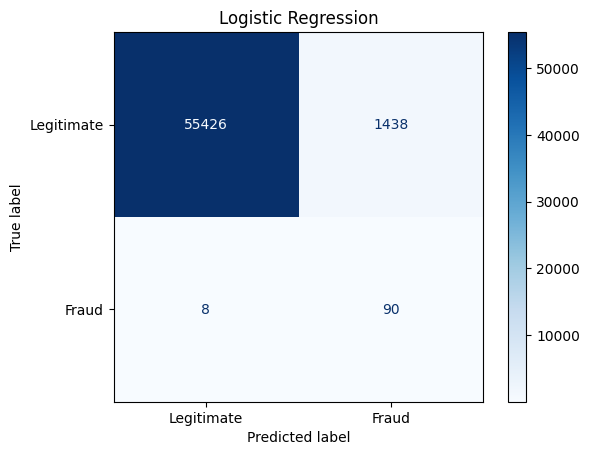


===== Random Forest =====
              precision    recall  f1-score   support

           0     0.9998    0.9986    0.9992     56864
           1     0.5148    0.8878    0.6517        98

    accuracy                         0.9984     56962
   macro avg     0.7573    0.9432    0.8254     56962
weighted avg     0.9990    0.9984    0.9986     56962

Test ROC-AUC: 0.9853427583751565


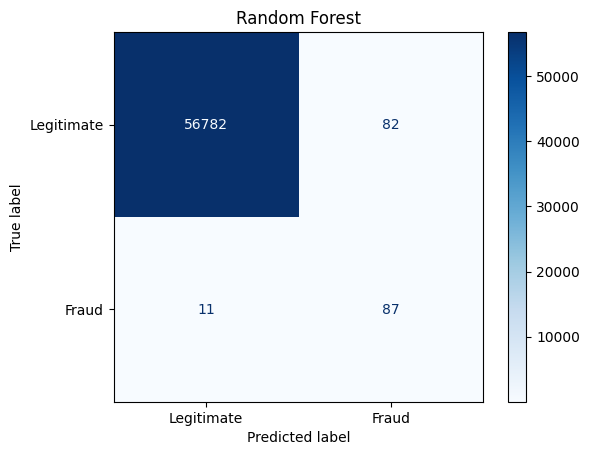

In [11]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in [('Logistic Regression', lr_grid), ('Random Forest', rf_grid)]:
    print(f"\n===== {name} =====")
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, y_pred, digits=4))
    print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
    disp.plot(cmap='Blues')
    plt.title(name)
    plt.show()

In [12]:
import json

results = {
    "logistic_regression": {
        "best_params": lr_grid.best_params_,
        "test_roc_auc": roc_auc_score(y_test, lr_grid.predict_proba(X_test)[:,1])
    },
    "random_forest": {
        "best_params": rf_grid.best_params_,
        "test_roc_auc": roc_auc_score(y_test, rf_grid.predict_proba(X_test)[:,1])
    }
}
with open("results_summary.json", "w") as f:
    json.dump(results, f, indent=2)

print(results)

{'logistic_regression': {'best_params': {'classifier__C': 0.1, 'smote__k_neighbors': 3}, 'test_roc_auc': np.float64(0.9715404926039072)}, 'random_forest': {'best_params': {'classifier__max_depth': 10, 'classifier__n_estimators': 50, 'smote__k_neighbors': 5}, 'test_roc_auc': np.float64(0.9853427583751565)}}
